In [15]:
import os
from tests.test_minio import test_minio_auth_basic

os.environ["MINIO_ENDPOINT"] = "https://s3.ciseiplan.netiswork.pro.br"
print(os.environ["MINIO_ENDPOINT"])
os.environ["MINIO_DEM_ROOT_KEY"] = "root/dem-datasets/"
print(os.environ["MINIO_DEM_ROOT_KEY"])

import importlib
from pathlib import Path
import cisei_lib.io.minio_access as mi
import cisei_lib.core.profiles.geo_info as gi
from cisei_lib.core.profiles.geo_info import DSFlags, P2PLink
import cisei_lib.core.profiles.geo_info_vector as giv
import cisei_lib.dem.dem_utils as du
import cisei_lib.dem.gob_footprints_utils as gfu
from datetime import timedelta


# Let's look at the query construction again
# import inspect
# source = inspect.getsource(bldg_utils.get_precise_fresnel_buildings)

test_minio_auth_basic()
ed_asa = -25.43188285765169, -49.27605438684823
pucpr = -25.451376951255053, -49.252777095141084
jd_botanico = -25.440793108803657, -49.237824902742794
museu = -25.409689697407796, -49.267060498223586
torre = -25.424018797077057, -49.29405137264106
aguas = -25.32655151248675, -49.48982604505564 # ouro fino
estancia = -25.333175041912444, -49.47289659207633  # ouro fino
pico_marumbi = -25.44143390372285, -48.91460293567934
mirante = -25.47427673417167, -49.37857169050803 # passauna
passauna = -25.531417164785577, -49.38315688140852 # entrada
cabana = -25.501460412412808, -49.36641387345384 # passauna
haras = -25.49548204119312, -49.364266535708275 #passauna
canil = -25.548927261016246, -49.06013873722329 # pinhais
chacara = -25.57486380898891, -48.96916942408549 # pinhais
radio_A = -25.746627, -53.01808
radio_B = -25.77999, -53.0108

radio_C= -24.992171, -52.244346 # MRQ-R-GE-016
radio_D = -25.030943, -52.233516 # MRQ-R-GE-017

https://s3.ciseiplan.netiswork.pro.br
root/dem-datasets/
https://s3.ciseiplan.netiswork.pro.br
Testing MinIO authentication for bucket: planapp
✅ Connection and authentication successful.
Bucket 'planapp' is accessible.


## TEST 1 (BASIC): select and initicalize dataset, find tiff, create raster and plot1D profiles

In [5]:
importlib.reload(du)
importlib.reload(giv)
#gio = gi.geoInfo()
gio = giv.geoInfoVector()

test = {   
    "select_dataset": True,
    "path_data": True,
    "get_profile": True,
    "select_bldg": True
}
 
if test['select_dataset']:
    # Select datasets with no points returns the first dataset available
    ds_key, tiles = gio.select_dataset(DSFlags.DTM, [ed_asa, torre, museu] )
    print(ds_key, tiles)
    ds_key, tiles = gio.select_dataset(DSFlags.DSM, [ed_asa, torre, museu, estancia, pico_marumbi] )
    print(ds_key, tiles)
    file_path = gio.find_tiff(DSFlags.DSM, *ed_asa)
    print(file_path)
    src = gio.get_cached_raster(DSFlags.DTM, *pico_marumbi)
    print(gio.iscoord(src, *torre))
    print(gio.iscoord(src, *pico_marumbi))   
# Find tiles by path is used to segment paths covered by single tiles
if test['path_data']:    
    ds_key, tiles = gio.select_dataset(gi.DSFlags.DTM, [ed_asa, torre, museu, pico_marumbi] )
    print(du.find_tiles_by_path(gio.index_geojson['DTM'], ed_asa, pico_marumbi))
    src = gio.get_cached_raster(gi.DSFlags.DSM, *ed_asa)
    print(du.get_samples(src, [ed_asa, torre]))
    path = du.get_path_data_from_src(src, ed_asa, torre)
    print(path[0],'to' ,path[-1])
if test['get_profile']: 
    # Multi-tile function with automatic dataset and tile selection.
    path = gio.get_1D_profile(gi.DSFlags.DSM, ed_asa, torre)
    print(path[0],'to' ,path[-1])
    path = gio.get_1D_profile(gi.DSFlags.DSM, ed_asa, estancia)
    print(path[0],'to' ,path[-1])
if test['select_bldg']:
    ds_key, tiles = gio.select_dataset(DSFlags.BLDG, [ed_asa, torre, museu])
    file_path = gio.find_tiff(DSFlags.BLDG, *ed_asa)

    print(f"Dataset Path: {ds_key}")
    print(f"Required Parquet Tiles: {tiles}")
    print(f"BLDG file: {file_path}")

    

root/dem-datasets/dtm/anadem-dtm-parana ['s26_w050.tif']
root/dem-datasets/dsm/copernicus-dsm-parana ['Copernicus_DSM_COG_10_S26_00_W049_00_DEM.tif', 'Copernicus_DSM_COG_10_S26_00_W050_00_DEM.tif']
root/dem-datasets/dsm/copernicus-dsm-parana/Copernicus_DSM_COG_10_S26_00_W050_00_DEM.tif
False
True
[((-25.43188285765169, -49.27605438684823), (-25.43917618393073, -49.00004447675389), 's26_w050.tif'), ((-25.43917618394028, -49.00004447639244), (-25.44143390372285, -48.91460293567934), 's26_w049.tif')]
[901.0903 955.9797]
[  0.       901.090271] to [2009.15139929  955.97967529]
[  0.       901.090271] to [2009.15139929  955.97967529]
[  0.       901.090271] to [22626.86600085   988.12744141]
Dataset Path: root/dem-datasets/bldg/gob-h-parana-parquets
Required Parquet Tiles: ['OpenBuildings_S26_W50.parquet']
BLDG file: root/dem-datasets/bldg/gob-h-parana-parquets/OpenBuildings_S26_W50.parquet


## TEST 2 (INTERMEDIARY): extract profile

In [ ]:
from cisei_lib.core.profiles.geo_info import DSFlags, FresnelProfile
import numpy as np
importlib.reload(gi)
importlib.reload(du)
gio = gi.geoInfo()

test = {   
    "dtm_dict": True,
    "lulc_plot": False,
    "build_profiles": False,
    "raw_plots": False,
    "plot_profiles" : False,
    "audit_trees": False,
}

link = P2PLink(radio_A, radio_B, 7, 7, 900)

if test['dtm_dict']:
    ds_flag = DSFlags.DTM
    dtm_dict = gio.create_2D_dictionary(link, ds_flag)
    du.plot_surface_dict(dtm_dict)
if test['lulc_plot']:
    ds_flag = DSFlags.COVER
    lulc_dict = gio.create_2D_dictionary(link, ds_flag)
    du.plot_surface_dict(lulc_dict, gio.cover_legend)
if test['build_profiles']:
    gio.initialize_2D_dictionaries(link)
    profile = gio.extract_fresnel_profile(link, -1, mode='linear_max')
    res_dtm = np.column_stack((profile.distances, profile.dtm_h))    
    res_dsm = np.column_stack((profile.distances, profile.dsm_h))
    res_lulc = np.column_stack((profile.distances, profile.lulc_ids))
    res_clutter = np.column_stack((profile.distances, profile.clutter_h))
    print(profile.segs)
if test['raw_plots']:
    ds_key, tiles = gio.select_dataset(gi.DSFlags.DSM, [link.tx,link.rx] )        
    src = gio.get_cached_raster(gi.DSFlags.DSM, *link.tx)    
    raw_dsm =  du.get_path_data_from_src(src, link.tx, link.rx)
    ds_key, tiles = gio.select_dataset(gi.DSFlags.DTM, [link.tx, link.rx] )        
    src = gio.get_cached_raster(gi.DSFlags.DTM, *link.tx)    
    raw_dtm =  du.get_path_data_from_src(src, link.tx, link.rx)    
    du.plot_data_tuples(raw_dtm, raw_dsm, labels=['dtm_raw', 'dsm_raw'], figsize=(12.5,6) )     
if test['plot_profiles']:
    gio.initialize_2D_dictionaries(link)
    lulc_heights = { gio._get_clutter_id('tree') : 10, gio._get_clutter_id('buil') : -10 }   
    du.plot_combined_profiles(res_dtm, res_dsm, res_lulc, lulc_heights ) 
if test['audit_trees']:    
    gio.initialize_2D_dictionaries(link)
    res_ch = du.get_high_res_tree_profile(tx, rx, res_lulc, gio.cover_legend)
    v_values = [v for _, v in res_ch if v != 0]
    percentiles = np.percentile(v_values, [25, 50, 75, 90])
    print('Three heights', percentiles)  
    lulc_heights = { gio._get_clutter_id('tree') : 10, gio._get_clutter_id('buil') : -10 }   
    res_lulc = [lulc_heights.get(v, 0) for v in profile.lulc_ids]    
    res_lulc = np.column_stack((profile.distances, res_lulc))    
    du.plot_advanced_profiles(res_dtm, res_dsm, res_lulc, res_ch)
    du.plot_data_tuples(res_clutter, res_ch, res_lulc, labels=['dsm_clutter', 'trees', 'lulc'], figsize=(12.5,6) )   


## TEST 3 (DTM and DSM invasions): evaluate a profile and return Fresnel invasions of terrain and clutter

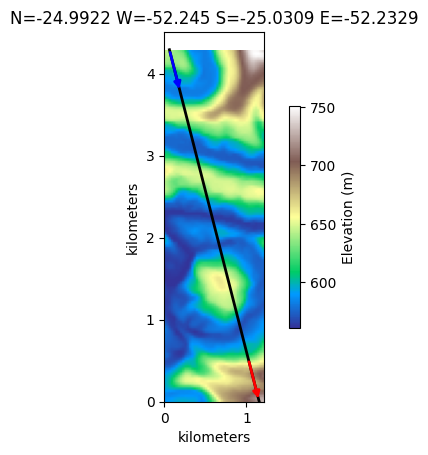

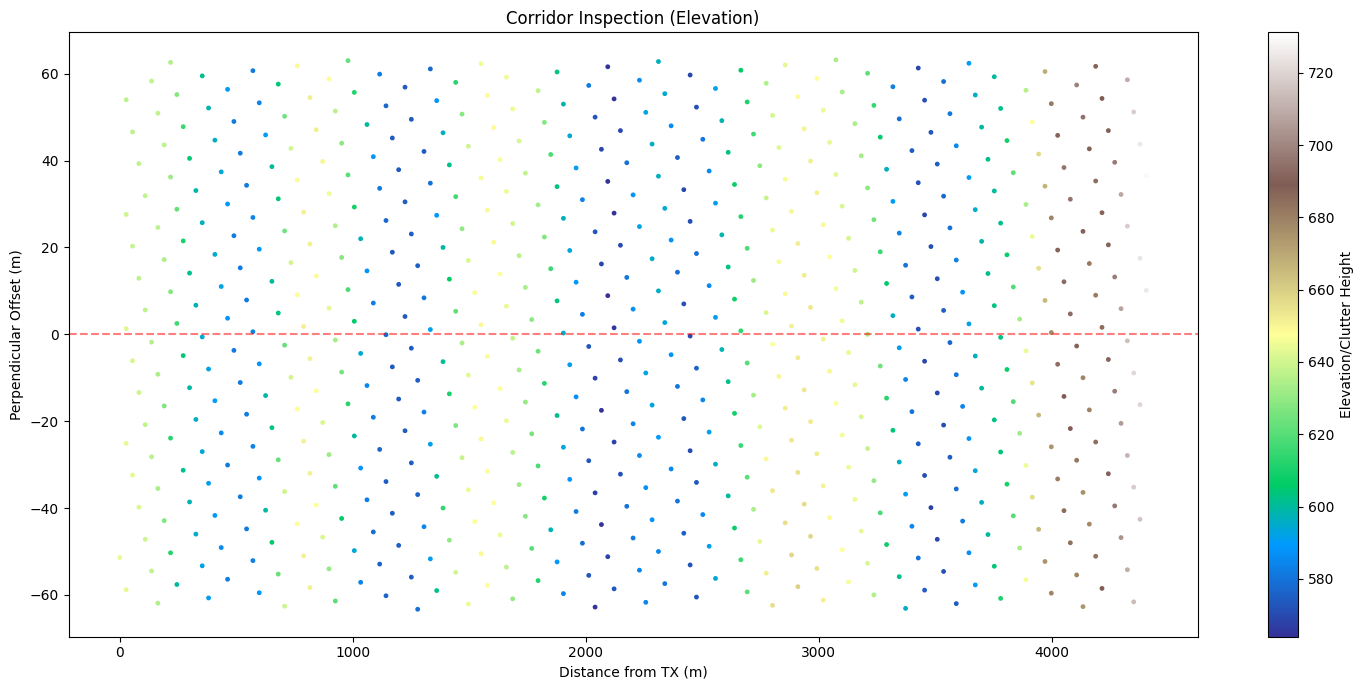

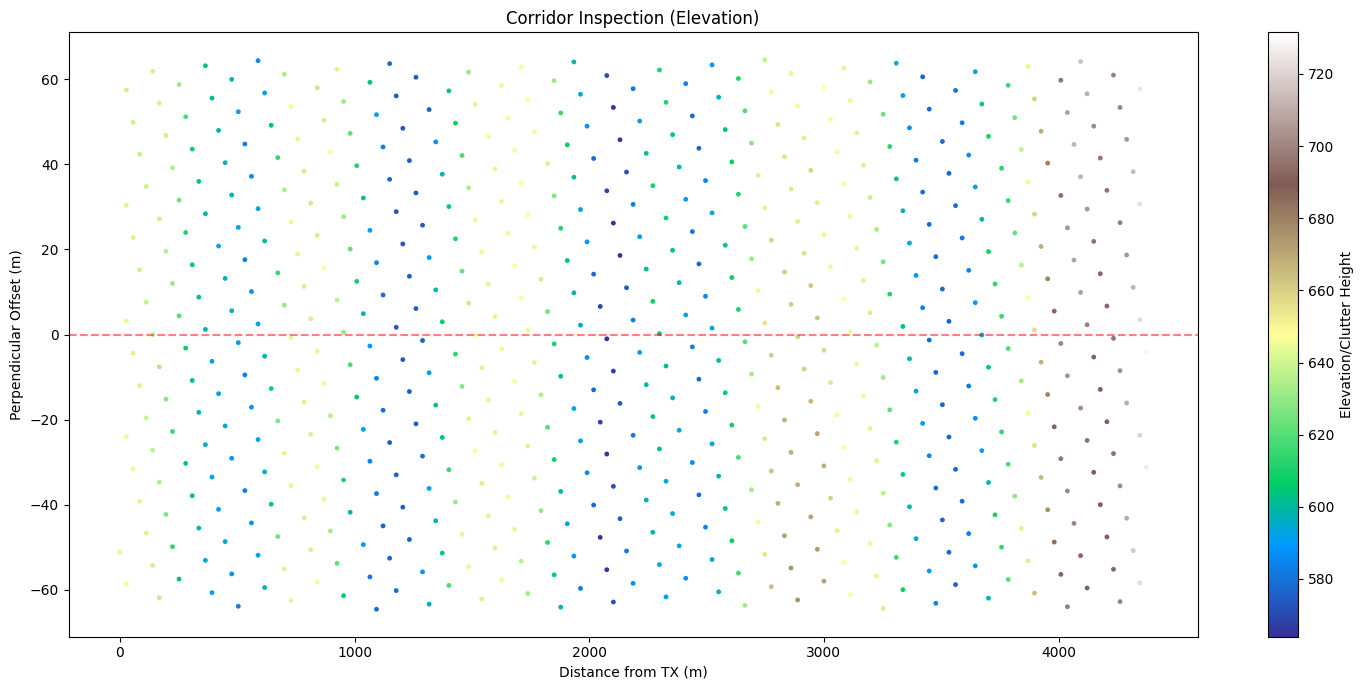

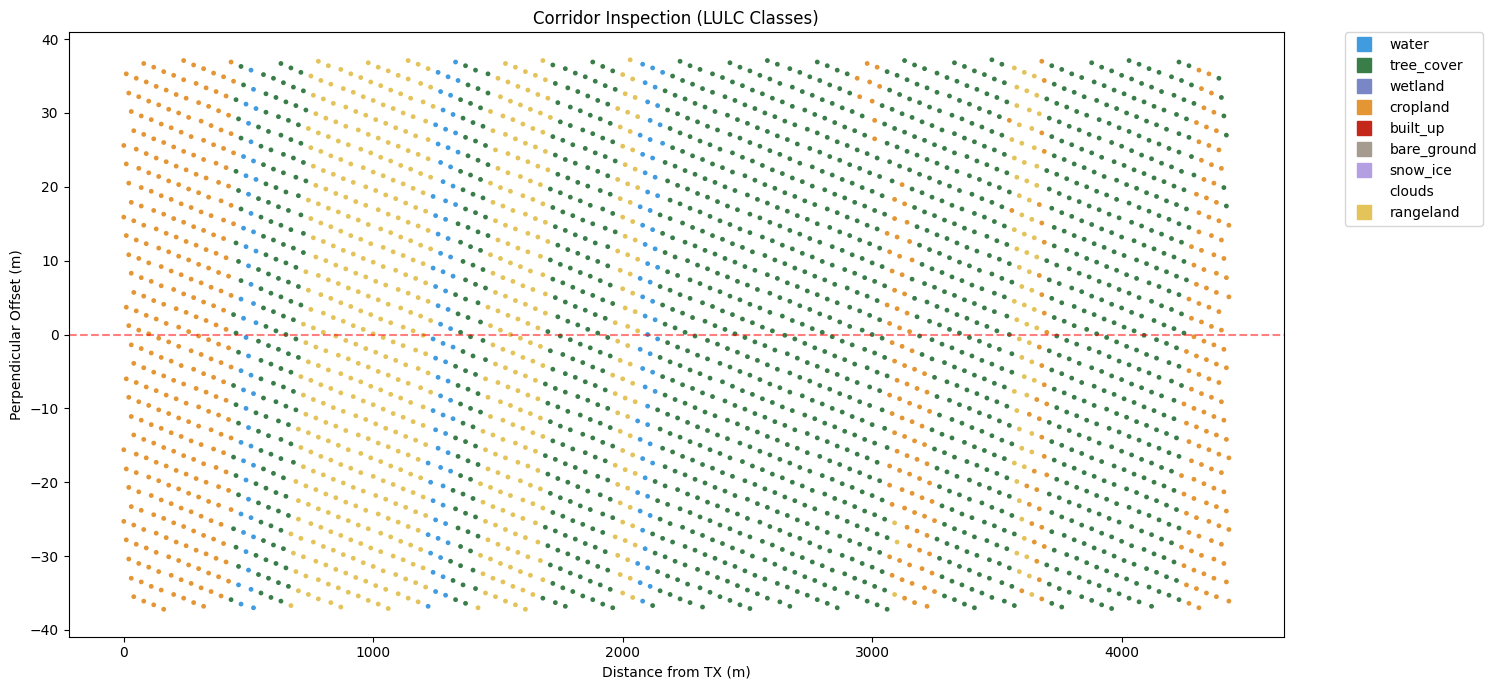

(15, 7)


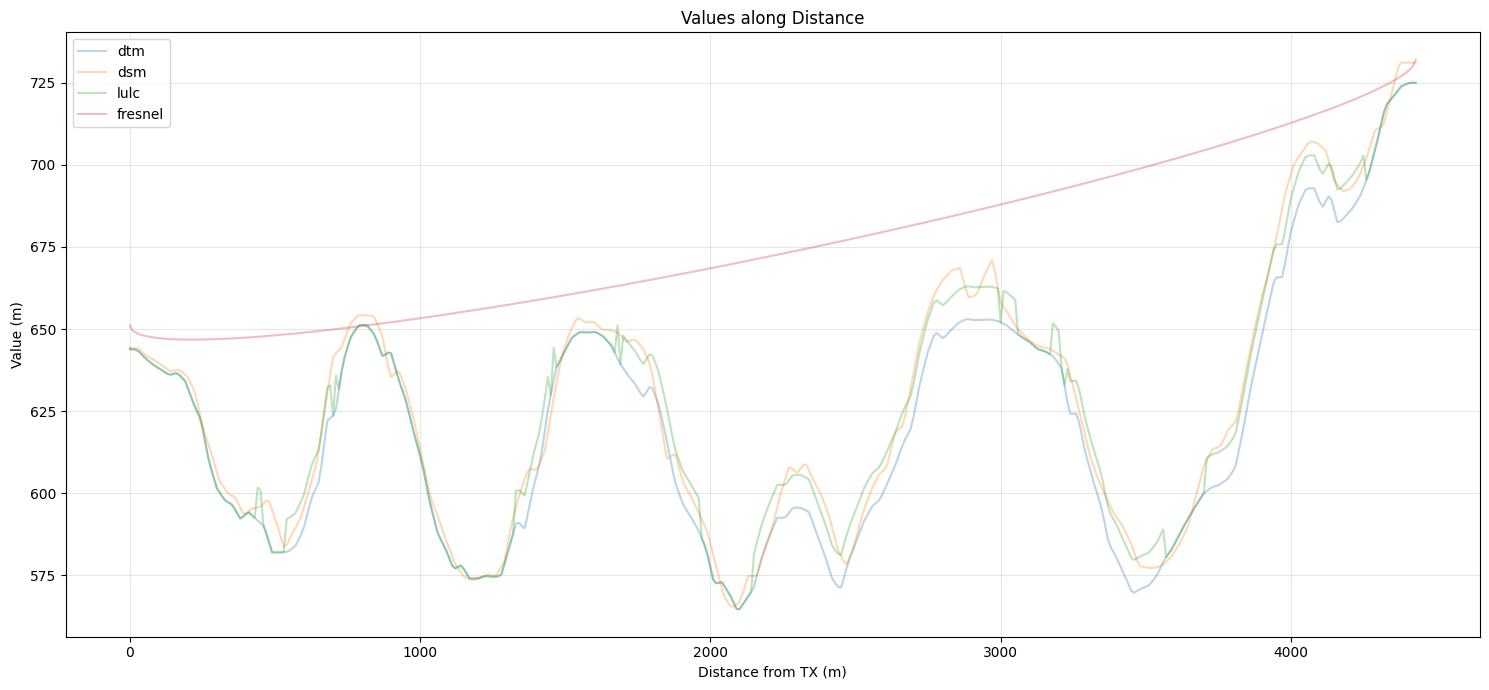

In [51]:
import numpy as np
import cisei_lib.core.profiles.geo_tools as gt
from IPython.display import display, Image
import base64
 
importlib.reload(du)
importlib.reload(gi)
importlib.reload(gt)


gio = gi.geoInfo()

link = P2PLink(radio_C, radio_D, 7, 7, 900)
img_str = gio.create_b64_map(link) 
display(Image(data=base64.b64decode(img_str)))

gio.initialize_2D_dictionaries(link)
#data = gio.create_2D_dictionary(link, DSFlags.DTM) 
#du.plot_surface_dict(data)
du.plot_surface_dict(gio.dtm_dict)
du.plot_surface_dict(gio.dsm_dict)
du.plot_surface_dict(gio.lulc_dict, gio.cover_legend)
gio.show_fresnel_profiles(link, v_h = 0, v_v = -1)  


## TEST 4 (BASIC): plot profiles

In [15]:
gio = gi.geoInfo()
gio.select_dataset(DSFlags.DSM, [passauna, cabana])
du.find_tiles_by_path_with_bboxes(gio.index_geojson['DSM'], passauna, cabana, 900)

[{'file': 'Copernicus_DSM_COG_10_S26_00_W050_00_DEM.tif',
  'bbox': (-49.383342009010114,
   -25.53150756573264,
   -49.36622880458593,
   -25.50136999259482),
  'tx': (-25.531417164785577, -49.38315688140852),
  'rx': (-25.5014604124128, -49.36641387345384),
  'radius': 21.12972699033136}]

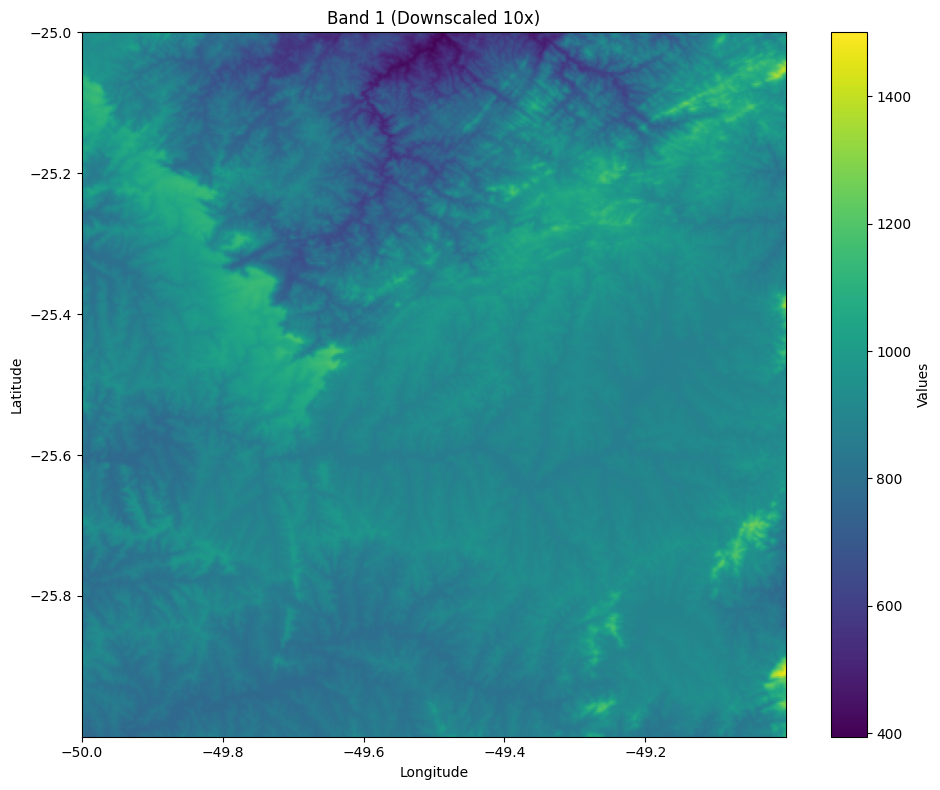

In [5]:
from cisei_lib.core.profiles.geo_info import DSFlags, FresnelProfile
from datetime import timedelta
import base64
import cisei_lib.core.plot.geo_plot as gp
from IPython.display import display, Image
import importlib
import cisei_lib.core.profiles.geo_info as gi
import cisei_lib.dem.dem_utils as du
importlib.reload(gi)
importlib.reload(du)
importlib.reload(gp)

test = {   
    "map": False,
    "link": False,
    "signed_url": True
}

# du.show_lulc_fresnel_zone_from_srcs = show_lulc_fresnel_zone_v1_2

if test["map"]:
    gio = gi.geoInfo()
    img_str = gio.create_b64_map(passauna, cabana, ds_flag= DSFlags.DTM)
    display(Image(data=base64.b64decode(img_str)))
if test['link']:    
    gio = gi.geoInfo()
    link = P2PLink(jd_botanico, pucpr, 7, 7, 900)
    img_str = gio.create_b64_link(link, w=4000, h=1000, dpi=200, v_h = 0.6)
    display(Image(data=base64.b64decode(img_str)))
if test['signed_url']:
    gio = gi.geoInfo()
    ds_key, tiles = gio.select_dataset(gi.DSFlags.DTM, [ed_asa, torre, museu] )
    file_path = gio.find_tiff(gi.DSFlags.DTM, *ed_asa)
    url = gio.repo_access.get_object_url(file_path, timedelta(seconds=10))    
    img_str = du.show_tiff_band(url, return_base64 = True, downscale_factor=10)
    display(Image(data=base64.b64decode(img_str)))
    #gio.show_lulc_fresnel_zone(link, downscale=1)


## TEST 5 (building invasions): Test buildings

Registering UDF...
908.0900268554688 1055.5399780273438


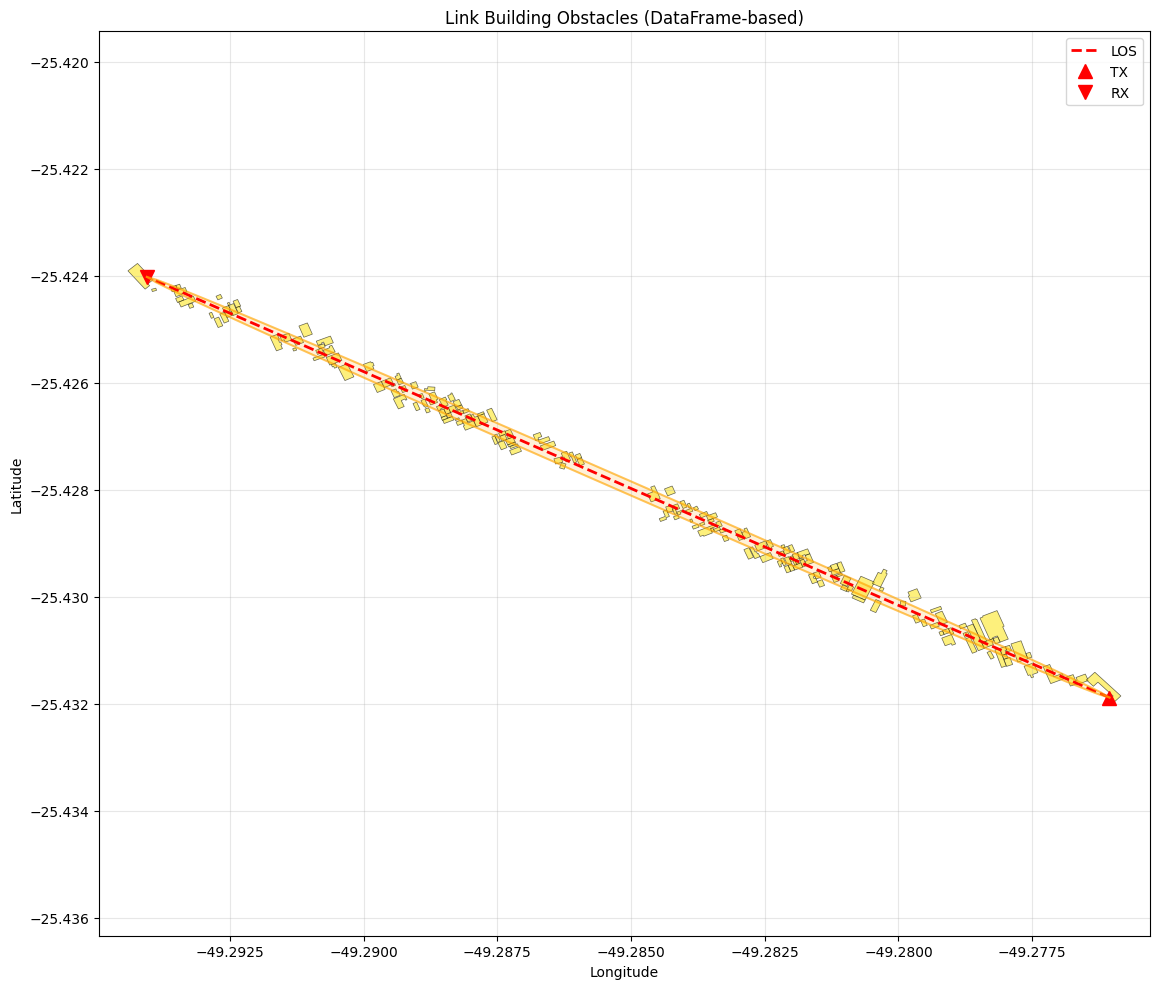

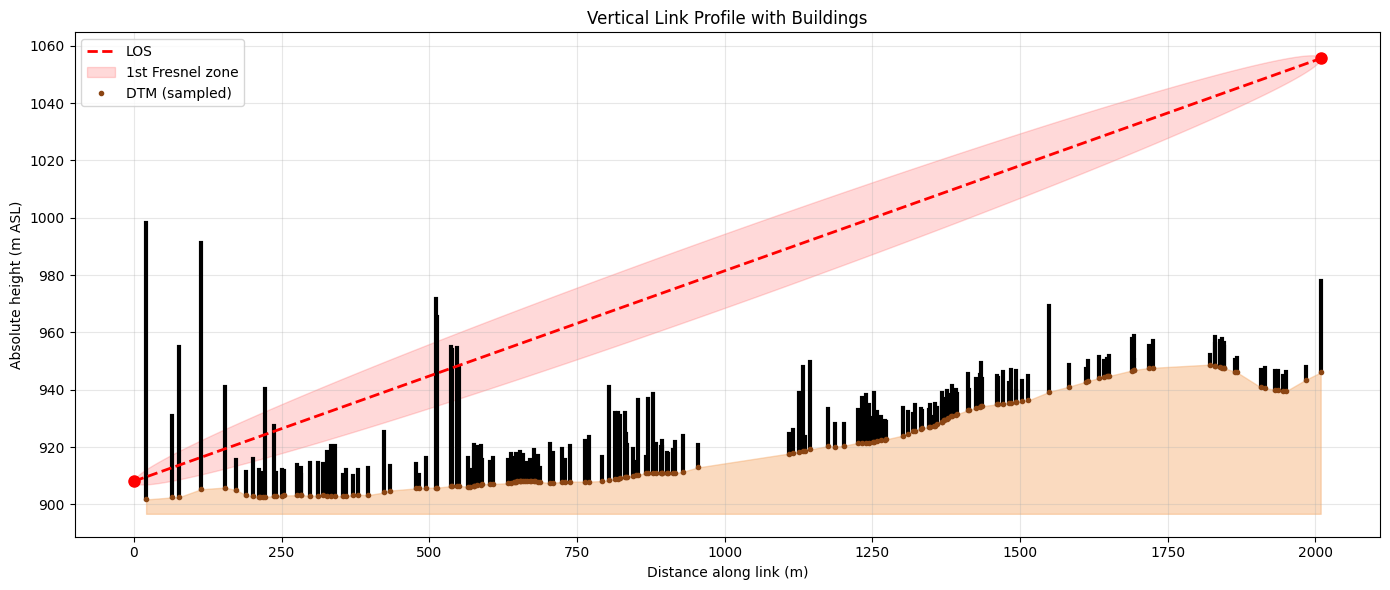

        d_los_m  dh_los_m  p90_h    v_v_top  v_v_base
59    20.722363       0.0   96.5  33.912251 -3.008443
164  113.718308       0.0   86.0  12.524020 -1.862186


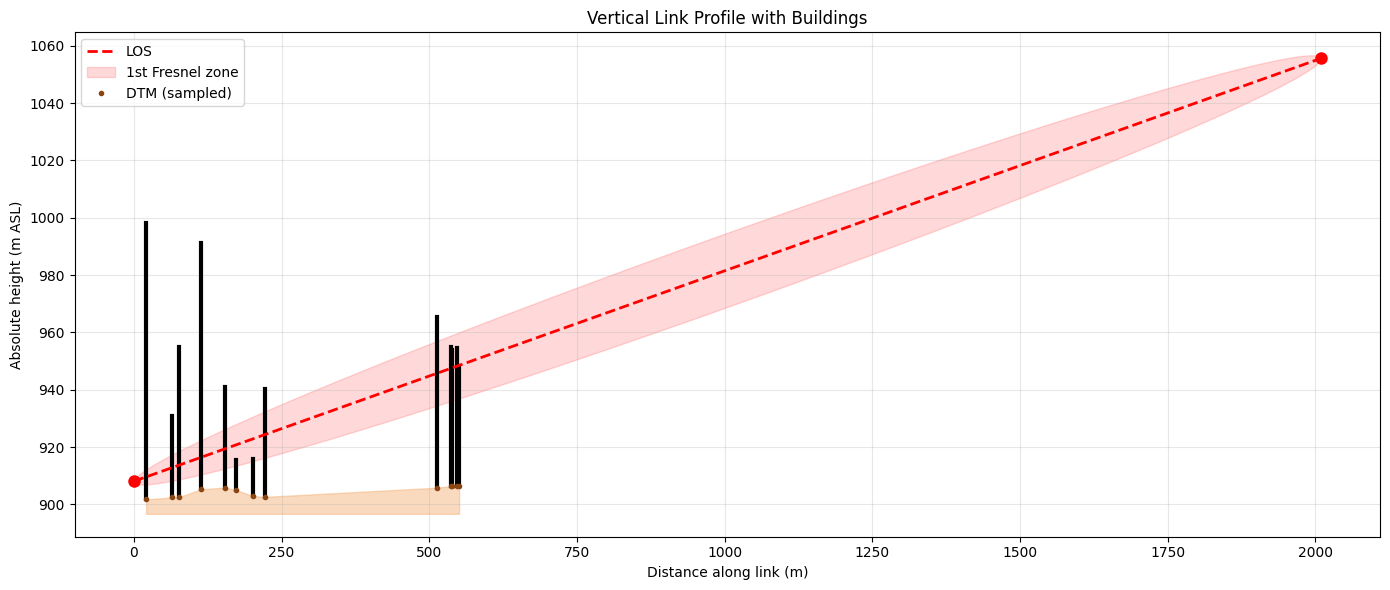

In [8]:
import cisei_lib.core.profiles.geo_tools as gt
importlib.reload(gfu) # google footprint utils
importlib.reload(giv)
importlib.reload(gi)
importlib.reload(gt)
#gio = gi.geoInfo()
from time import time

test = {   
    "test_parquets":False,
    "load_bldg" : False,
    "create_dataframe": True,
    "plot_dataframe" : True, # requires create_dataframe
    "filter_by_fresnel" : True,
    "invasions" : False # requires filter_by_fresnel
}

link = P2PLink(ed_asa, torre, 7, 109.5, 900)

if test['test_parquets']:
    gio = giv.geoInfoVector()
    print(gio.select_dataset(DSFlags.BLDG, [ed_asa,torre]))  
    print(du.find_tiles_by_list(gio.index_geojson[DSFlags.BLDG.name],[ed_asa]))
    print(len(gio.index_geojson[DSFlags.BLDG.name]['features']))
    print(gio.dataset_keys[DSFlags.BLDG.name])
if test['load_bldg']:
    gio = giv.geoInfoVector()
    # This should trigger download + DuckDB insertion
    start = time()
    success = gio.get_cached_buildings([ed_asa, museu])
    print (success, time() - start)
    print('should not wait because it is the same parquet')
    success = gio.get_cached_buildings([pucpr, jd_botanico])
    print (success, time() - start)
    
    # Verify the DuckDB state
    loaded = gio.vector_con.execute("SELECT * FROM loaded_tiles").fetchall()
    count = gio.vector_con.execute("SELECT count(*) FROM buildings").fetchone()[0]
    
    print(f"Load Success: {success}")
    print(f"Tiles in Cache: {loaded}")
    print(f"Total Buildings Paged: {count}")

    gfu.check_db_bounds(gio.vector_con)
    gfu.check_db_schema(gio.vector_con)
    print(gfu.check_top_buildings(gio.vector_con, 50, 2))
if test['create_dataframe']:
    gio = giv.geoInfoVector()
    gio.initialize_2D_dictionaries(link, DSFlags.DTM)
    gio.create_link_dataframe(link)  
    print(gio.link.tx_ha_abs, gio.link.rx_ha_abs)    
if test['plot_dataframe']:
    gio.plot_link_horizontal_profile(gio.building_df)
    gio.plot_link_vertical_profile(gio.building_df)
if test['filter_by_fresnel']:
    filtered_df = gio.filter_buildings_by_fresnel(-1, -1)
    temp = filtered_df.sort_values(by='v_v_top', ascending=False)
    print(temp[['d_los_m', 'dh_los_m', 'p90_h', 'v_v_top', 'v_v_base']].head(2))
    gio.plot_link_vertical_profile(filtered_df)
if test['invasions']:
    zones, invasions = gio.buildings_radial_invasions(filtered_df)
    print(zones)
    browser = gio.building_browser(invasions)

    

Showing: 586GHP9C+GR78 | v_h: -0.79 | v_v_top: -0.9992818396420432


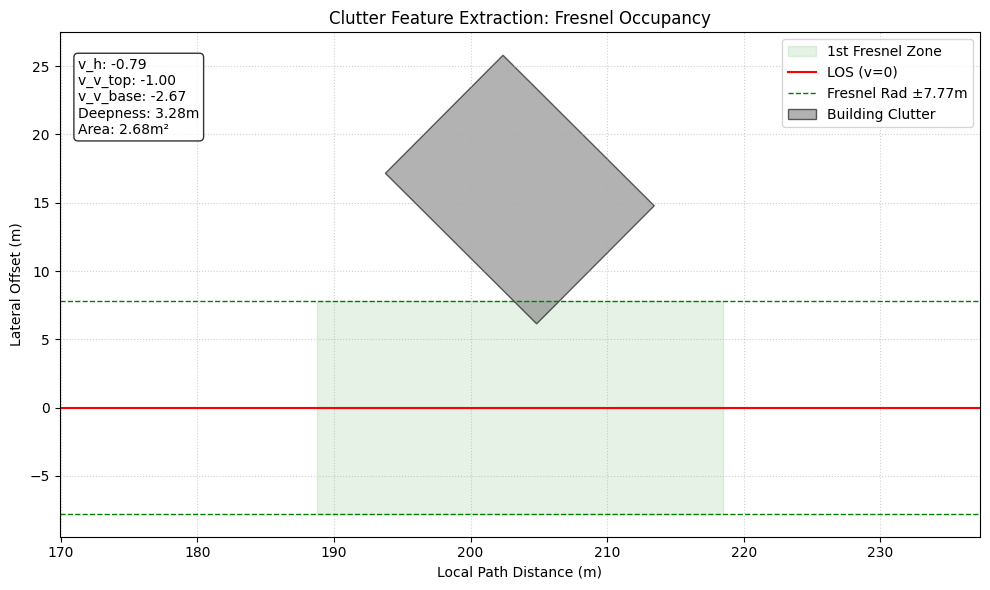

In [426]:
gio.get_next_invasion(browser)

In [29]:
import inspect

def hello(name: str, times: int = 1):
    return ("Hello, " + name + "! ") * times


def make_wrapper(fn):
    sig = inspect.signature(fn)
    print("Original signature:", sig)

    def wrapper(**kwargs):
        print("Wrapper received:", kwargs)
        return fn(**kwargs)

    wrapper.__signature__ = sig
    return wrapper


wrapped = make_wrapper(hello)

print(wrapped(name="Alice"))
print(wrapped(name="Bob", times=3))

Original signature: (name: str, times: int = 1)
Wrapper received: {'name': 'Alice'}
Hello, Alice! 
Wrapper received: {'name': 'Bob', 'times': 3}
Hello, Bob! Hello, Bob! Hello, Bob! 


In [31]:
import inspect
importlib.reload(du)
from cisei_lib.dem.dem_utils import get_quadkey
print(repr(inspect.getdoc(get_quadkey)))

'Returns the Bing Maps quadkey for a latitude, longitude, and zoom level.\n\nArgs:\n    lat: Latitude in degrees\n    lon: Longitude in degrees\n    level: Zoom level'
